# 0. Load imports 

In [23]:
## imports
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

## print multiple things from same cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## load data on 2020 crimes in DC
df = dc_crim_2020 = pd.read_csv("https://opendata.arcgis.com/datasets/f516e0dd7b614b088ad781b0c4002331_2.csv")

# 1. Questions: list comprehension

- In class example, why did we need the "courses" at the beginning of the list iteration
- How did the join syntax work in the example where we paste together offenses from same ward

In [24]:
## toy example

### pool of courses
all_courses = ["QSS20", "QSS17", "GOV10", "GOV4", "CSC1"]


## 1.1 Application 1: filtering to a smaller list

When we might use: have a lot of columns in a dataframe; want to filter to a smaller set using some pattern

In [25]:
### pull out ones that contain GOV in the string
gov_c = [course for course in all_courses if "GOV" in course]
gov_c # result

['GOV10', 'GOV4']

In [26]:
### showing that the "course" is just a placeholder/
### arbitrary interator
gov_c_alt = [x for x in all_courses if "GOV" in x]

gov_c == gov_c_alt

True

## 1.2 Application two: keep all objects in the list but do some transformation

In [27]:
all_courses

## strip the numbers from the course names
courses_prefix = [x[:3] for x in all_courses]
courses_prefix # could then find unique elements


['QSS20', 'QSS17', 'GOV10', 'GOV4', 'CSC1']

['QSS', 'QSS', 'GOV', 'GOV', 'CSC']

In [9]:
# Join all together example
" #:(# ".join(courses_prefix)

'QSS #:(# QSS #:(# GOV #:(# GOV #:(# CSC'

#### Your turn: Using original list, add "dartmouth_" prefix to the course name

In [40]:
["dartmouth_" + x for x in all_courses]

['dartmouth_QSS20',
 'dartmouth_QSS17',
 'dartmouth_GOV10',
 'dartmouth_GOV4',
 'dartmouth_CSC1']

## 1.3 Subsetting columns

Use list comprehension to filter to columns with id in the string. Then, create a new dataframe called df1 that contains only column heads with "id"

In [29]:
id_cols = [col for col in df.columns if "ID" in col]
id_cols

## Then, filter the data
df[id_cols]

['BID', 'OBJECTID', 'OCTO_RECORD_ID']

,BID,OBJECTID,OCTO_RECORD_ID
0,DUPONT CIRCLE,976657932,NaN
1,NaN,976657941,NaN
2,NaN,976657942,NaN
3,NaN,976657945,NaN
4,NaN,976657959,NaN
...,...,...,...
27927,NaN,977253793,NaN
27928,NaN,977253794,NaN
27929,NaN,977253796,NaN
27930,NaN,977253826,NaN


In [31]:
df1=df[id_cols]
df1

,BID,OBJECTID,OCTO_RECORD_ID
0,DUPONT CIRCLE,976657932,NaN
1,NaN,976657941,NaN
2,NaN,976657942,NaN
3,NaN,976657945,NaN
4,NaN,976657959,NaN
...,...,...,...
27927,NaN,977253793,NaN
27928,NaN,977253794,NaN
27929,NaN,977253796,NaN
27930,NaN,977253826,NaN


## 1.4 Comprehension for numbers

Here we compare two ways of creating a list of even numbers.

In [12]:
num_list = np.arange(10000)
num_list

array([   0,    1,    2, ..., 9997, 9998, 9999], shape=(10000,))

In [13]:
%%time
even_nums = [i for i in num_list if (i % 2) == 0]

CPU times: user 2.11 ms, sys: 734 μs, total: 2.84 ms
Wall time: 3.28 ms


In [14]:
%%time
num_list[~(num_list % 2).astype(bool)]

CPU times: user 1.28 ms, sys: 2.56 ms, total: 3.84 ms
Wall time: 3.88 ms


array([   0,    2,    4, ..., 9994, 9996, 9998], shape=(5000,))

In [15]:
num_list[ ~(num_list % 2).astype(bool) ]

array([   0,    2,    4, ..., 9994, 9996, 9998], shape=(5000,))

#### Your turn: Extract all numbers in num_list that end in 7

In [32]:
seven_nums = [i for i in num_list if (i%10)==7]
seven_nums

[np.int64(7),
 np.int64(17),
 np.int64(27),
 np.int64(37),
 np.int64(47),
 np.int64(57),
 np.int64(67),
 np.int64(77),
 np.int64(87),
 np.int64(97),
 np.int64(107),
 np.int64(117),
 np.int64(127),
 np.int64(137),
 np.int64(147),
 np.int64(157),
 np.int64(167),
 np.int64(177),
 np.int64(187),
 np.int64(197),
 np.int64(207),
 np.int64(217),
 np.int64(227),
 np.int64(237),
 np.int64(247),
 np.int64(257),
 np.int64(267),
 np.int64(277),
 np.int64(287),
 np.int64(297),
 np.int64(307),
 np.int64(317),
 np.int64(327),
 np.int64(337),
 np.int64(347),
 np.int64(357),
 np.int64(367),
 np.int64(377),
 np.int64(387),
 np.int64(397),
 np.int64(407),
 np.int64(417),
 np.int64(427),
 np.int64(437),
 np.int64(447),
 np.int64(457),
 np.int64(467),
 np.int64(477),
 np.int64(487),
 np.int64(497),
 np.int64(507),
 np.int64(517),
 np.int64(527),
 np.int64(537),
 np.int64(547),
 np.int64(557),
 np.int64(567),
 np.int64(577),
 np.int64(587),
 np.int64(597),
 np.int64(607),
 np.int64(617),
 np.int64(627),
 np

#### Your turn: Divide each number  in num_list by 2

In [34]:
divide = [i / 2 for i in num_list]
print(divide)

[np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0), np.float64(5.5), np.float64(6.0), np.float64(6.5), np.float64(7.0), np.float64(7.5), np.float64(8.0), np.float64(8.5), np.float64(9.0), np.float64(9.5), np.float64(10.0), np.float64(10.5), np.float64(11.0), np.float64(11.5), np.float64(12.0), np.float64(12.5), np.float64(13.0), np.float64(13.5), np.float64(14.0), np.float64(14.5), np.float64(15.0), np.float64(15.5), np.float64(16.0), np.float64(16.5), np.float64(17.0), np.float64(17.5), np.float64(18.0), np.float64(18.5), np.float64(19.0), np.float64(19.5), np.float64(20.0), np.float64(20.5), np.float64(21.0), np.float64(21.5), np.float64(22.0), np.float64(22.5), np.float64(23.0), np.float64(23.5), np.float64(24.0), np.float64(24.5), np.float64(25.0), np.float64(25.5), np.float64(26.0), np.float64(26.5), np.float64(27.0), np.float64(27.5), np.float64(

# 2. Questions: lambda functions

Two questions:

- General syntax (see here for a reference: https://www.w3schools.com/python/python_lambda.asp 
- How they work in the context of aggregations

How is a lambda function different from a "normal" user-defined function (that has the syntax def func_name(arg): etc?

- Operates similarly to normal user-defined functions in that it can take any # of arguments
- Operates differently in that it's an "anonymous" function or a function that we don't explicitly name/save in memory

## 2.1 General syntax for lambda functions

In [35]:
### two pools of courses
socsci = ["QSS20", "QSS17", "GOV10"]
natsci = ["BIO2", "PHYS3"]


## generalize some of the steps
## above into a two-arg function
## that takes the course prefix
## and a list of all courses
def filter_courses(prefix, all_courses):
    rel_courses = [c for c in all_courses if prefix in c]
    return(rel_courses)

### a few applications 
filter_courses(prefix = "QSS", all_courses = socsci)
filter_courses(prefix = "QSS", all_courses = natsci)
filter_courses(prefix = "BIO", all_courses = natsci)

['QSS20', 'QSS17']

[]

['BIO2']

In [36]:
## what's the lambda function version of this
filter_courses_v2 = lambda prefix, all_courses: [c for c in all_courses if prefix in c]
filter_courses_v2(prefix = "BIO", all_courses = natsci)


['BIO2']

## 2.2 using alongside agg

In [37]:
## use lambda to find modal block in a ward- multiple ways

### way 1: subsetting agg syntex
df.groupby("WARD")["BLOCK"].agg(lambda x: x.mode())

### way 2: dictionary agg syntax
df.groupby("WARD").agg({"BLOCK": lambda x: x.mode()})


WARD
1                  3100 - 3299 BLOCK OF 14TH STREET NW
2    [1100 - 1199 BLOCK OF NEW YORK AVENUE NW, 1300...
3             5300 - 5399 BLOCK OF WISCONSIN AVENUE NW
4                100  - 199 BLOCK OF CARROLL STREET NW
5            900 - 999 BLOCK OF RHODE ISLAND AVENUE NE
6                       600 - 699 BLOCK OF H STREET NE
7                934 - 1099 BLOCK OF EASTERN AVENUE NE
8               2300 - 2399 BLOCK OF GOOD HOPE ROAD SE
Name: BLOCK, dtype: object

,BLOCK
WARD,
1,3100 - 3299 BLOCK OF 14TH STREET NW
2,"[1100 - 1199 BLOCK OF NEW YORK AVENUE NW, 1300..."
3,5300 - 5399 BLOCK OF WISCONSIN AVENUE NW
4,100 - 199 BLOCK OF CARROLL STREET NW
5,900 - 999 BLOCK OF RHODE ISLAND AVENUE NE
6,600 - 699 BLOCK OF H STREET NE
7,934 - 1099 BLOCK OF EASTERN AVENUE NE
8,2300 - 2399 BLOCK OF GOOD HOPE ROAD SE


#### Your turn: Group by WARD and get the mean and standard deviation (std) of X and Y

In [38]:
df.groupby("WARD")[["X", "Y"]].agg(["mean", "std"])

X                           Y             
               mean          std           mean          std
WARD                                                        
1     397289.867555   624.307287  139648.610621   712.362815
2     396621.067712  1223.488923  137564.793599   595.099248
3     393470.489099  1162.323901  141520.418724  1541.617708
4     397841.637555  1023.793670  143307.153700  1545.603726
5     400915.575468  1297.551690  139152.417438  1416.967174
6     399898.301927   980.505436  136139.856333  1112.374544
7     404563.412110  1626.707129  135648.075402  1388.268228
8     400956.107708  1110.298221  131412.540814  1751.194450

### Random sampling and distance measures

In [41]:
random_uniform = np.random.rand(5)  # 5 random numbers between 0 and 1
print("Random numbers from uniform distribution:", random_uniform)

random_normal = np.random.randn(5)  # 5 random numbers from a standard normal distribution
print("Random numbers from normal distribution:", random_normal)

Random numbers from uniform distribution: [0.31351418 0.02481656 0.2260871  0.31406249 0.05897413]
Random numbers from normal distribution: [-0.55615966 -1.11435277 -0.43596954  1.11056221  1.2845295 ]


<Axes: ylabel='Density'>

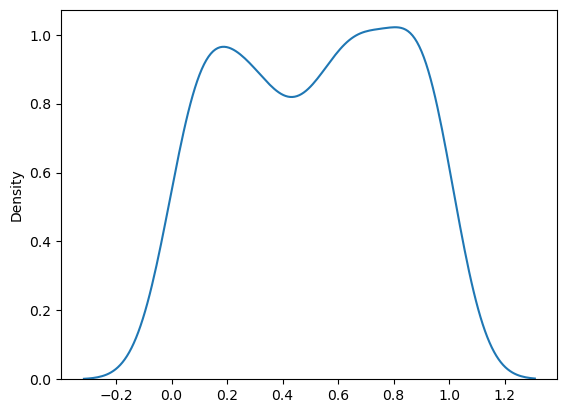

In [42]:
N = 200

sns.kdeplot(np.random.rand(N))

<Axes: ylabel='Density'>

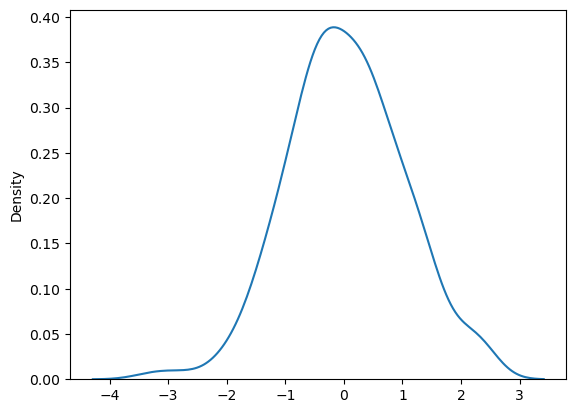

In [43]:
sns.kdeplot(np.random.randn(N))